Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

Loading Data

In [3]:
cols = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak',
    'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv("processed.cleveland.data", header=None, names=cols)   # change filename if needed

df = df.replace('?', np.nan)

df = df.dropna()

df = df.apply(pd.to_numeric)

df['target'] = (df['target'] > 0).astype(int)

print(df.head())
print(df['target'].value_counts())

print("Original Shape:", df.shape)   

print("\nFirst 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  
target
0    160
1    137
Name: count, dtype: int64
Original Shape: (297, 14)

First 5 Rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0

Handling missing values

In [4]:
df = df.replace('?', np.nan)

missing_cols = df.columns[df.isna().any()]

print("\nColumns with missing values:")
for col in missing_cols:
    print(f"{col}: {df[col].isna().sum()} missing")

rows_with_missing = df.isna().any(axis=1).sum()
print("\nRows containing missing values:", rows_with_missing)

df = df.dropna()

print("Shape after dropping missing rows:", df.shape)
print("Final retained row count:", len(df))


Columns with missing values:

Rows containing missing values: 0
Shape after dropping missing rows: (297, 14)
Final retained row count: 297


In [5]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col])


TARGET CLASS DISTRIBUTION

In [6]:
target_counts = df['target'].value_counts().sort_index()
target_percent = df['target'].value_counts(normalize=True).sort_index() * 100

print("\nTarget Class Distribution:")
for cls in target_counts.index:
    print(f"Class {cls}: {target_counts[cls]} ({target_percent[cls]:.2f}%)")

# Brief balance check
minority_ratio = target_counts.min() / target_counts.max()

if minority_ratio < 0.80:
    print("\nDataset is moderately imbalanced.")
    use_smote = True
else:
    print("\nDataset is reasonably balanced.")
    use_smote = False


Target Class Distribution:
Class 0: 160 (53.87%)
Class 1: 137 (46.13%)

Dataset is reasonably balanced.


TRAIN / TEST SPLIT (before scaling)

In [7]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)



Train shape: (237, 13)
Test shape : (60, 13)


ENCODING + STANDARDIZATION

In [8]:
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# One-hot encode
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align test columns with training columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Standardize continuous columns (fit only on training set)
scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

APPLY SMOTE ONLY ON TRAINING SPLIT

In [9]:
if use_smote:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    print("\nAfter SMOTE:")
    print(pd.Series(y_train).value_counts())

CORRELATION HEATMAP (before encoding)

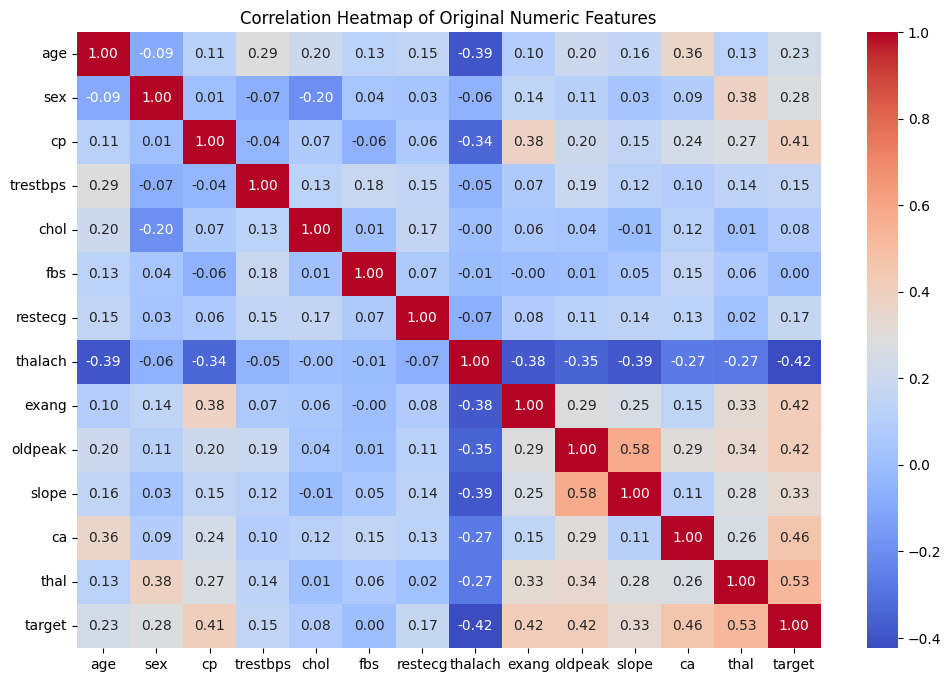

In [10]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Original Numeric Features")
plt.show()

TOP 3 STRONGEST CORRELATIONS

In [11]:
corr_matrix = numeric_df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

top_pairs = upper.unstack().dropna().sort_values(ascending=False)

print("\nTop 3 Strongest Correlated Feature Pairs:")
for i in range(3):
    pair = top_pairs.index[i]
    value = top_pairs.iloc[i]
    print(f"{pair[0]} - {pair[1]} : {value:.3f}")


Top 3 Strongest Correlated Feature Pairs:
slope - oldpeak : 0.579
target - thal : 0.527
target - ca : 0.463
